In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pickle
from pathlib import Path
from IPython.display import Audio
import IPython.display as ipd
from scipy.io import wavfile
import tempfile
import os
import librosa
import pandas as pd
import seaborn as sns
import h5py
import mne
from scipy.stats import zscore
from mne_bids import BIDSPath, read_raw_bids
from matplotlib_venn import venn2,venn2_circles
from tqdm import tqdm

In [ ]:
cm = 1/2.54
plt.rcParams['svg.fonttype'] = 'none'

fontdict = dict(fontsize=7)
fontsize = 7

red = '#A9373B'
blue = '#2369BD'
orange = '#CC8963'
green = '#009944'

stg_color = '#20B2AA'
smc_color = '#6A5ACD'
insula_color = '#D4AF37'

reds = sns.light_palette(red, as_cmap=True)
blues = sns.light_palette(blue, as_cmap=True)
oranges = sns.light_palette(orange, as_cmap=True)
greens = sns.light_palette(green, as_cmap=True)

recon_dir = '/cwork/ns458/ECoG_Recon/'
mne.viz.set_3d_backend('notebook')                    # MNE 3D in-notebook static backend
# text svg

# Load HGA

In [ ]:
import pandas as pd
import numpy as np
from mne_bids import BIDSPath
from tqdm import tqdm

task = [
        'LexicalNoDelay',
        'LexicalDelay',
        'PictureNaming',
        'SentenceRep',
        'PhonemeSequence',
        # 'TIMIT'
        ]


ref = 'bipolar'
hga_paths = []
for t in task:
    hga_paths.extend(
        BIDSPath(
            root=f'../results/{t}({ref})',
            datatype='HGA',
            suffix='time',  # 注意这里改成 'time'
            check=False,
        ).match()
    )

# 2. 筛选 perception 和 passive 的数据
HGAs = []
for path in tqdm(hga_paths):
    df = pd.read_csv(path)
    # 只保留 perception 或 passive
    HGAs.append(df)

HGAs = pd.concat(HGAs)

# rename both phase : Resp and Response to Resp
HGAs.loc[HGAs.phase == 'Resp', 'phase'] = 'Response'
HGAs.loc[HGAs.phase == 'Audio', 'phase'] = 'Stimulus'

# phase all convert to lower
HGAs['phase'] = HGAs['phase'].str.lower()

# rename INS to 'Insula'
HGAs.loc[HGAs.roi == 'INS', 'roi'] = 'Insula'
# combine HG to STG
# HGAs.loc[HGAs.roi == 'HG', 'roi'] = 'STG'
HGAs.loc[HGAs.roi == 'PrG', 'roi'] = 'SMC'
HGAs.loc[HGAs.roi == 'PoG', 'roi'] = 'SMC'
HGAs.loc[HGAs.roi == 'Subcentral', 'roi'] = 'SMC'


HGAs.loc[HGAs.label.isin([
    'ctx_lh_G_and_S_cingul-Mid-Post',
    'ctx_rh_G_and_S_cingul-Mid-Post',
    'ctx_lh_G_cingul-Post-dorsal'
    ]), 'roi'] = 'PCC'


dacc_labels = [
    'ctx_lh_G_and_S_cingul-Mid-Ant',
    'ctx_rh_G_and_S_cingul-Mid-Ant'
]
HGAs.loc[HGAs.label.isin(dacc_labels), 'roi'] = 'dACC' # 这里的 dACC 就是最严格的 SN 枢纽
# rename CG to ACC
HGAs.loc[HGAs.roi=='CG', 'roi'] = 'ACC'
HGAs.head()

In [ ]:
# load a exlude pandas df
fpath = '../results/exlude_insula.csv'
exclude_df = pd.read_csv(fpath, index_col=0)
# exclude NaN columns and flatten into single list
exclude_chn = [electrode for item in exclude_df.Exclude.dropna() 
                for electrode in eval(item)]

HGAs = HGAs[~HGAs.channel.isin(exclude_chn)]
print(exclude_chn)

In [ ]:
# Insula region classification function for row-wise application
def classify_insula_row(row, y_threshold=0):
    """
    Classify a single insula electrode into AIC or PIC
    Designed for use with df.apply()
    
    Returns: 'AIC', 'PIC', or original roi if not insula
    """
    if row['roi'] != 'Insula':
        return row['roi']
    
    label = row['label']
    y_coord = row['y']
    
    # AIC classification conditions
    if ('G_insular_short' in label or 
        'S_circular_insula_ant' in label or
        ('S_circular_insula_sup' in label and y_coord > y_threshold) or
        ('S_circular_insula_inf' in label and y_coord > y_threshold)):
        return 'AIC'
    
    # PIC classification conditions  
    elif ('G_Ins_lg_and_S_cent_ins' in label or
          ('S_circular_insula_sup' in label and y_coord <= y_threshold) or
          ('S_circular_insula_inf' in label and y_coord <= y_threshold)):
        return 'PIC'
    
    # If no conditions match, return original
    return row['roi']

# Apply classification to entire DataFrame (function handles filtering internally)
HGAs['roi'] = HGAs.apply(classify_insula_row, axis=1, y_threshold=0)

# Statistics results
print(f"AIC electrode count: {len(HGAs[HGAs['roi'] == 'AIC'])}")
print(f"PIC electrode count: {len(HGAs[HGAs['roi'] == 'PIC'])}")

# Check unclassified electrodes
unclassified = HGAs[HGAs['roi'] == 'Insula']
if len(unclassified) > 0:
    print(f"Unclassified electrode count: {len(unclassified)}")
    print("Unclassified label types:", unclassified['label'].unique())
    
HGAs.head()

In [ ]:
fsavg_lh_surf, _ = mne.read_surface(f"{recon_dir}/fsaverage/surf/lh.pial")
cvs_lh_surf, _ = mne.read_surface(f"{recon_dir}/cvs_avg35_inMNI152/surf/lh.pial")
translation = cvs_lh_surf.mean(axis=0) - fsavg_lh_surf.mean(axis=0)
HGAs[['x','y','z']] = HGAs[['x','y','z']].values + translation

In [ ]:
import pandas as pd
import numpy as np
from mne_bids import BIDSPath
from tqdm import tqdm

task = [
        'LexicalNoDelay',
        'LexicalDelay',
        'PictureNaming',
        'SentenceRep',
        'PhonemeSequence',
        'TIMIT'
        ]

ref = 'bipolar'
hga_paths = []
for t in task:
    hga_paths.extend(
        BIDSPath(
            root=f'../results/{t}({ref})',
            datatype='HGA',
            suffix='zscore',  
            check=False,
        ).match()
    )

# 2. 筛选 perception 和 passive 的数据
ZAs = []
for path in tqdm(hga_paths):
    df = pd.read_csv(path)
    # 只保留 perception 或 passive
    ZAs.append(df)

ZAs = pd.concat(ZAs)

# rename both phase : Resp and Response to Resp
ZAs.loc[ZAs.phase == 'Resp', 'phase'] = 'Response'
ZAs.loc[ZAs.phase == 'Audio', 'phase'] = 'Stimulus'

# phase all convert to lower
ZAs['phase'] = ZAs['phase'].str.lower()

# rename INS to 'Insula'
ZAs.loc[ZAs.roi == 'INS', 'roi'] = 'Insula'
# combine HG to STG
# HGAs.loc[HGAs.roi == 'HG', 'roi'] = 'STG'
ZAs.loc[ZAs.roi == 'PrG', 'roi'] = 'SMC'
ZAs.loc[ZAs.roi == 'PoG', 'roi'] = 'SMC'
ZAs.loc[ZAs.roi == 'Subcentral', 'roi'] = 'SMC'


ZAs.loc[ZAs.label.isin([
    'ctx_lh_G_and_S_cingul-Mid-Post',
    'ctx_rh_G_and_S_cingul-Mid-Post',
    'ctx_lh_G_cingul-Post-dorsal'
    ]), 'roi'] = 'PCC'


dacc_labels = [
    'ctx_lh_G_and_S_cingul-Mid-Ant',
    'ctx_rh_G_and_S_cingul-Mid-Ant'
]
ZAs.loc[ZAs.label.isin(dacc_labels), 'roi'] = 'dACC' # 这里的 dACC 就是最严格的 SN 枢纽
# rename CG to ACC
ZAs.loc[ZAs.roi=='CG', 'roi'] = 'ACC'
ZAs.head()

In [ ]:
# Insula region classification function for row-wise application
def classify_insula_row(row, y_threshold=0):
    """
    Classify a single insula electrode into AIC or PIC
    Designed for use with df.apply()
    
    Returns: 'AIC', 'PIC', or original roi if not insula
    """
    if row['roi'] != 'Insula':
        return row['roi']
    
    label = row['label']
    y_coord = row['y']
    
    # AIC classification conditions
    if ('G_insular_short' in label or 
        'S_circular_insula_ant' in label or
        ('S_circular_insula_sup' in label and y_coord > y_threshold) or
        ('S_circular_insula_inf' in label and y_coord > y_threshold)):
        return 'AIC'
    
    # PIC classification conditions  
    elif ('G_Ins_lg_and_S_cent_ins' in label or
          ('S_circular_insula_sup' in label and y_coord <= y_threshold) or
          ('S_circular_insula_inf' in label and y_coord <= y_threshold)):
        return 'PIC'
    
    # If no conditions match, return original
    return row['roi']

# Apply classification to entire DataFrame (function handles filtering internally)
ZAs['roi'] = ZAs.apply(classify_insula_row, axis=1, y_threshold=0)

# Statistics results
print(f"AIC electrode count: {len(ZAs[ZAs['roi'] == 'AIC'])}")
print(f"PIC electrode count: {len(ZAs[ZAs['roi'] == 'PIC'])}")

# Check unclassified electrodes
unclassified = ZAs[ZAs['roi'] == 'Insula']
if len(unclassified) > 0:
    print(f"Unclassified electrode count: {len(unclassified)}")
    print("Unclassified label types:", unclassified['label'].unique())
    
ZAs.head()

In [ ]:
fsavg_lh_surf, _ = mne.read_surface(f"{recon_dir}/fsaverage/surf/lh.pial")
cvs_lh_surf, _ = mne.read_surface(f"{recon_dir}/cvs_avg35_inMNI152/surf/lh.pial")
translation = cvs_lh_surf.mean(axis=0) - fsavg_lh_surf.mean(axis=0)
ZAs[['x','y','z']] = ZAs[['x','y','z']].values + translation

# AIC is only active during when action is required

In [ ]:
rois = ['AIC']
# tasks = ['LexicalDelay', 'LexicalNoDelay', 'PictureNaming', 'SentenceRep', 'PhonemeSequence']
# tasks = ['LexicalDelay', 'LexicalNoDelay','SentenceRep','PictureNaming','PhonemeSequence']
# descs = ['Passive','Repeat','Decision']

tasks = ['LexicalNoDelay']

descs = ['Passive', 'Repeat']

colors = ['#00753f', '#a9373b', '#5c4ebd']
modality = 'sound'

subset = HGAs[
    (HGAs.task.isin(tasks))
    & (HGAs.roi.isin(rois))
    & (HGAs.hemi == 'L')
    # & (~HGAs.subject.isin(['D0121','D0064','D0123','D0125','D0118']))
    # & (HGAs.description.isin(['Passive']))
    & (HGAs.modality==modality)
]

subset_z = ZAs[
    (ZAs.task.isin(tasks))
    & (ZAs.channel.isin(subset.channel.unique()))
    & (ZAs.hemi == 'L')
    & (ZAs.time<1.5)
    & (ZAs.description.isin(descs))
    # & (~ZAs.subject.isin(['D0121','D0064','D0123','D0125','D0129','D0118']))
    & (ZAs.modality==modality)
]

phases = ['stimulus', 'response']
fig, axes = plt.subplots(nrows=1, ncols=len(phases), figsize=(2*(len(phases))*cm, 2.5*cm))

plt.subplots_adjust(wspace=0)

# Create plots with proper labels for legend
for (phase, ax) in zip(phases, axes):
        
    legend_ = True if ax==axes[1] else False
    sns.lineplot(
        data=subset_z[(subset_z.phase == phase)],
        x='time',
        y='value',
        hue='description',
        hue_order=descs,
        ax=ax,
        palette=colors,
        legend=legend_,
        lw=1
    )
    ax.set_xlabel(f'{phase.capitalize()} onset (s)', fontsize=7)   
    

for ax in fig.axes:
    ax.axvline(x=0, color='k', linestyle='--', linewidth=0.5)
    ax.axhline(y=0, color='k', linestyle='--', linewidth=0.5)
    
    ax.tick_params(labelsize=7, width=.75, length=2, which='both')
    plt.setp(ax.spines.values(), linewidth=.75)
    sns.despine(ax=ax, offset=1, trim=True)
    
    # Only add legend to the last axis if it has artists with labels
    if ax.get_legend() is not None:
        ax.legend(title='', fontsize=7)
    else:
        # Remove legend from other axes
        legend = ax.get_legend()
        if legend is not None:
            legend.remove()
    
    ax.set_yticklabels([])
    ax.set_yticks([])
    # remove y spine
    ax.spines['left'].set_visible(False)
    
    ax.set_ylim(-0.1, 0.8)
    
axes[0].set_ylabel('HGA (z)', fontsize=7)
for ax in axes[1:]:
    ax.set_ylabel('', fontsize=7)
    
# plt.suptitle(f'PictureNaming-AIC-{modality}', fontsize=9)
# plt.savefig(f'../img/misc/compare_across_conditions_{rois[0]}_{tasks[0]}_{modality}.svg', dpi=300, bbox_inches='tight')
plt.show()

## Spatial

In [26]:
desc = 'Repeat'
spatial = subset[
    (subset.phase == 'response')
    & (subset.description == desc)
    & (subset.modality == 'sound')
    & (subset.time>0)
    & (subset.time<1)
    ].groupby('channel').agg({
    'value': 'mean',  
    'x': 'first',
    'y': 'first', 
    'z': 'first',
    'roi': 'first',
    'label': 'first',
    'phase': 'first',
    'hemi': 'first',
    'subject': 'first',
    'description': 'first',
    'task': 'first'
}).reset_index()

spatial.rename(columns={'value': 'HGA'}, inplace=True)
spatial.head()

,channel,HGA,x,y,z,roi,label,phase,hemi,subject,description,task
0,D0022_LPIF3-4,1.037866,-33.806661,-2.826671,-21.194863,PIC,ctx_lh_S_circular_insula_inf,response,L,D0022,Repeat,SentenceRep
1,D0022_LPIF4-5,1.179111,-39.961647,-3.586756,-22.939045,PIC,ctx_lh_S_circular_insula_inf,response,L,D0022,Repeat,SentenceRep
2,D0028_LPI1-2,0.192538,-37.657943,9.625521,-28.763605,PIC,ctx_lh_G_Ins_lg_and_S_cent_ins,response,L,D0028,Repeat,LexicalNoDelay
3,D0028_LPI3-4,0.097151,-38.757869,10.460758,-12.935653,PIC,ctx_lh_S_circular_insula_sup,response,L,D0028,Repeat,LexicalNoDelay
4,D0094_LFPI10-11,0.238045,-37.078095,8.222419,-1.644450,PIC,ctx_lh_S_circular_insula_sup,response,L,D0094,Repeat,LexicalNoDelay


Reading labels from parcellation...
   read 75 labels from /cwork/ns458/ECoG_Recon/cvs_avg35_inMNI152/label/lh.aparc.a2009s.annot
   read 75 labels from /cwork/ns458/ECoG_Recon/cvs_avg35_inMNI152/label/rh.aparc.a2009s.annot


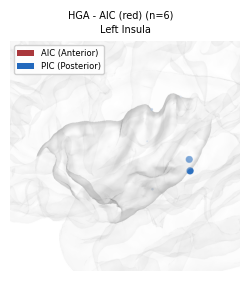

In [27]:
# ============================================================
# 3D Insula HGA Visualization - AIC (red) vs PIC (blue)
# 保持与 Cell 13 完全相同的参数，只改变颜色
# ============================================================

import numpy as np
import pyvista as pv
import matplotlib.pyplot as plt
from mne.viz import Brain
from scipy.spatial import cKDTree
import matplotlib.colors as mcolors

# 读取aparc.a2009s labels
labels = mne.read_labels_from_annot(
    subject='cvs_avg35_inMNI152', parc='aparc.a2009s',  
    surf_name='pial',
    hemi='both', subjects_dir=recon_dir,
)

# Insula相关的labels (aparc.a2009s)
insula_patterns = ['G_insular_short', 'G_Ins_lg_and_S_cent_ins', 
                   'S_circular_insula_ant', 'S_circular_insula_inf', 'S_circular_insula_sup']

# 加载pial表面用于投影
lh_pial_coords, _ = mne.read_surface(f"{recon_dir}/cvs_avg35_inMNI152/surf/lh.pial")
rh_pial_coords, _ = mne.read_surface(f"{recon_dir}/cvs_avg35_inMNI152/surf/rh.pial")
lh_tree = cKDTree(lh_pial_coords)
rh_tree = cKDTree(rh_pial_coords)

# 计算insula区域的中心点
def get_insula_center(labels, hemi, pial_coords):
    vertices = []
    for lab in labels:
        if lab.hemi == hemi and any(p in lab.name for p in insula_patterns):
            vertices.extend(lab.vertices)
    if vertices:
        insula_coords = pial_coords[vertices]
        return insula_coords.mean(axis=0)
    return None

lh_insula_center = get_insula_center(labels, 'lh', lh_pial_coords)
rh_insula_center = get_insula_center(labels, 'rh', rh_pial_coords)

# 创建左右半球Brain对象
lh_brain = Brain(
    "cvs_avg35_inMNI152", subjects_dir=recon_dir, surf="pial",
    hemi="lh", background="white", show=False,
    cortex=(0.9, 0.9, 0.9), alpha=0.05, size=(800, 800)
)
rh_brain = Brain(
    "cvs_avg35_inMNI152", subjects_dir=recon_dir, surf="pial",
    hemi="rh", background="white", show=False,
    cortex=(0.9, 0.9, 0.9), alpha=0.05, size=(800, 800)
)

# 添加insula labels (高亮显示)
for lab in labels:
    if any(pattern in lab.name for pattern in insula_patterns):
        if lab.hemi == 'lh':
            lh_brain.add_label(lab, borders=False, color=(0.9, 0.9, 0.9), alpha=0.6)
        elif lab.hemi == 'rh':
            rh_brain.add_label(lab, borders=False, color=(0.9, 0.9, 0.9), alpha=0.6)

# HGA数据 - 使用与 Cell 13 完全相同的数据
cord = spatial[['x', 'y', 'z']].values
hga_values = spatial['HGA'].values
roi_values = spatial['roi'].values

mask_lh = cord[:, 0] < 0
mask_rh = cord[:, 0] > 0

# 设置 colormap 和归一化 - 与 Cell 13 完全相同
# vmin, vmax = 0, np.percentile(hga_values, 95)
vmin, vmax = 0, 1
norm = mcolors.Normalize(vmin=vmin, vmax=vmax)

# 点大小映射参数 - 与 Cell 13 完全相同
size_min, size_max = 5, 25

def hga_to_size(hga, vmin, vmax, size_min, size_max):
    normalized = np.clip((hga - vmin) / (vmax - vmin), 0, 1)
    return size_min + normalized * (size_max - size_min)

def add_electrodes_with_hga_colored(brain, coords, hga_vals, roi_vals, tree, pial_coords, size_min, size_max):
    _, indices = tree.query(coords)
    coords_proj = pial_coords[indices]
    
    for i in range(len(coords_proj)):
        pt = coords_proj[i:i+1]
        hga = hga_vals[i]
        roi = roi_vals[i]
        
        # 根据ROI设置颜色，其他参数与 Cell 13 完全相同
        if roi == 'AIC':
            cmap = reds
            color = cmap(norm(hga))  # Anterior insula = red
        elif roi == 'PIC':
            cmap = blues
            color = cmap(norm(hga))  # Posterior insula = blue
        else:
            color = 'gray'  # 其他ROI用灰色
        
        size = hga_to_size(hga, vmin, vmax, size_min, size_max)
        
        cloud = pv.PolyData(pt)
        brain._renderer.plotter.add_mesh(
            cloud,
            render_points_as_spheres=True,
            point_size=size,
            color=color,
            lighting=False,  # 与 Cell 13 完全相同，无 opacity 参数
        )

# 添加左半球电极
if mask_lh.any():
    lh_cord = cord[mask_lh]
    lh_hga = hga_values[mask_lh]
    lh_roi = roi_values[mask_lh]
    add_electrodes_with_hga_colored(lh_brain, lh_cord, lh_hga, lh_roi, lh_tree, lh_pial_coords, 
                                    size_min, size_max)

# 添加右半球电极
if mask_rh.any():
    rh_cord = cord[mask_rh]
    rh_hga = hga_values[mask_rh]
    rh_roi = roi_values[mask_rh]
    add_electrodes_with_hga_colored(rh_brain, rh_cord, rh_hga, rh_roi, rh_tree, rh_pial_coords, 
                                    size_min, size_max)

# 设置视角 - 聚焦在insula中心
lh_brain.show_view(azimuth=180, elevation=90, distance=180, focalpoint=lh_insula_center)
rh_brain.show_view(azimuth=0, elevation=90, distance=180, focalpoint=rh_insula_center)

# 截图并显示
fig, axes = plt.subplots(1, 1, figsize=(8*cm, 8*cm))

axes.imshow(lh_brain.screenshot(mode="rgb"))
axes.axis("off")
axes.set_title("Left Insula", fontsize=fontsize)

# 添加图例说明颜色
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor=red, label='AIC (Anterior)'),
    Patch(facecolor=blue, label='PIC (Posterior)')
]
axes.legend(handles=legend_elements, loc='upper left', fontsize=fontsize-1, framealpha=0.9)

plt.suptitle("HGA - AIC (red) (n={})".format(len(spatial)), fontsize=fontsize)

lh_brain.close()
rh_brain.close()

plt.subplots_adjust(bottom=0.15)

# plt.savefig(f'../img/misc/condition_difference_spatial_{rois[0]}_{desc}_picturenaming.svg', dpi=300, bbox_inches='tight')

# Ave across channels: to get the significant clusters in a ROI

In [ ]:
bids_root = '/cwork/ns458/BIDS-1.0_LexicalDecRepDelay/BIDS/'

In [ ]:
# load label array
phases = ['Stimulus', 'Delay', 'Go', 'Response']
conditions = ['Decision','Repeat']

epos = []

for phase in tqdm(phases):
    
    for sub in subset.subject.unique():
        
        picks = subset[subset.subject==sub].channel.unique().tolist()
        
        pt = BIDSPath(
            root=os.path.join(bids_root, 'derivatives', 'epoch(bipolar)'),
            subject=sub,
            datatype='epoch(band)(zscore)',
            processing=phase,
            suffix='highgamma',
            extension='.h5',
            check=False
        )

        for condition in conditions:
            epo_path = pt.update(description=condition).match()[0]
            dc_epo = mne.read_epochs(epo_path, verbose='error')
            dc_epo.pick(picks)
            data = dc_epo.get_data()            # (trial, channel, time)
            times = dc_epo.times

            mean_ch = data.mean(axis=1)         # (trial, time)
            trial_ids = [f"{sub}_trial{i}" for i in range(mean_ch.shape[0])]
            df = pd.DataFrame(mean_ch, columns=times)
            df['trial'] = trial_ids
            df = df.melt(id_vars=['trial'], var_name='time', value_name='value')
            df['condition'] = condition
            df['phase'] = phase.lower()
            df['subject'] = sub
            epos.append(df)

epos = pd.concat(epos, ignore_index=True)
epos.head()

100%|██████████| 4/4 [00:11<00:00,  2.90s/it]


,trial,time,value,condition,phase,subject
0,D0063_trial0,-1.0,0.007218,Decision,stimulus,D0063
1,D0063_trial1,-1.0,-0.779275,Decision,stimulus,D0063
2,D0063_trial2,-1.0,-1.509975,Decision,stimulus,D0063
3,D0063_trial3,-1.0,-0.170949,Decision,stimulus,D0063
4,D0063_trial4,-1.0,-0.581638,Decision,stimulus,D0063


In [ ]:
from ieeg.calc.stats import time_perm_cluster

perms = []

for phase in tqdm(phases):
    # 保留 trial，先按 channel 平均得到 (trial, time)
    dec_df = epos[(epos.condition == 'Decision') & (epos.phase == phase.lower())]
    rep_df = epos[(epos.condition == 'Repeat') & (epos.phase == phase.lower())]
    # pivot to (trial x time)
    decision = dec_df.pivot(index='trial', columns='time', values='value').sort_index(axis=1)
    repeat   = rep_df.pivot(index='trial', columns='time', values='value').sort_index(axis=1)

    # 置换检验：trial 为观测，time 为维度
    mask, p = time_perm_cluster(
        decision.values,
        repeat.values,
        p_thresh=0.05,
        n_perm=2000,
        n_jobs=-1
    )
    times = decision.columns.values

    df = pd.DataFrame({
        'time': times,
        'mask': mask,
        'pval': p,
        'phase': phase.lower()
    })
    perms.append(df)
        
perms = pd.concat(perms, ignore_index=True)
perms.head()

100%|██████████| 4/4 [00:38<00:00,  9.63s/it]


,time,mask,pval,phase
0,-1.000000,False,0.065967,stimulus
1,-0.992188,False,0.033483,stimulus
2,-0.984375,False,0.013493,stimulus
3,-0.976562,False,0.008496,stimulus
4,-0.968750,False,0.011494,stimulus


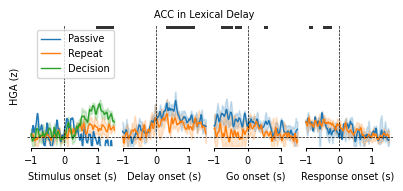

In [ ]:
colors = [red, blue]

fig, (ax1, ax2, ax3, ax4) = plt.subplots(nrows=1, ncols=4, figsize=(12*cm, 4*cm),gridspec_kw={'width_ratios': [2.5, 2.5, 2.5, 2.5]})

plt.subplots_adjust(wspace=0)

for (ax, phase) in zip(fig.axes, ['stimulus', 'delay', 'go', 'response']):
    
    # only add the legend to the first axis
    legend = False if ax != fig.axes[0] else True
    mask = perms.loc[perms.phase == phase, 'mask'].values
    pvals = perms.loc[perms.phase == phase, 'pval'].values
    
    line = sns.lineplot(
        data=subset[(subset.phase == phase)],
        x='time',
        y='value',
        hue='description',
        ax=ax,
        legend=legend,
        lw=1
    )
    
    # set a consistent y-range first
    ax.set_ylim(-0.1, 1.2)
    ymin, ymax = ax.get_ylim()
    pad = 0.01 * (ymax - ymin)
    bar_h = 0.02 * (ymax - ymin)

    times = perms.loc[perms.phase == phase, 'time'].values
    sig = (mask.astype(bool)) & (pvals < 0.05)

    if sig.any():
        ax.fill_between(
            times,
            ymax + pad,
            ymax + pad + bar_h,
            where=sig,
            color='k',
            alpha=0.8,
            step='mid',
            linewidth=0
        )

    ax.set_ylim(ymin, ymax + pad + bar_h + 0.01*(ymax - ymin))


for ax in fig.axes:
    ax.axvline(x=0, color='k', linestyle='--', linewidth=0.5)
    ax.axhline(y=0, color='k', linestyle='--', linewidth=0.5)
    
    ax.tick_params(labelsize=7, width=.75, length=2, which='both')
    plt.setp(ax.spines.values(), linewidth=.75)
    
    sns.despine(ax=ax, offset=1, trim=True)
    
    # Only add legend to the last axis if it has artists with labels
    if ax.get_legend() is not None:
        ax.legend(title='', fontsize=7)
    else:
        # Remove legend from other axes
        legend = ax.get_legend()
        if legend is not None:
            legend.remove()
    
    ax.set_yticklabels([])
    ax.set_yticks([])
    # remove y spine
    ax.spines['left'].set_visible(False)
    
    
ax1.set_xlabel('Stimulus onset (s)', fontsize=7)   
ax2.set_xlabel('Delay onset (s)', fontsize=7)   
ax3.set_xlabel('Go onset (s)', fontsize=7)   
ax4.set_xlabel('Response onset (s)', fontsize=7)   
ax1.set_ylabel('HGA (z)', fontsize=7)
ax2.set_ylabel('', fontsize=7)
ax3.set_ylabel('', fontsize=7)
ax4.set_ylabel('', fontsize=7)

plt.suptitle(rois[0] + ' in Lexical Delay', fontsize=7)
plt.savefig(f'../img/fig4/fig4_{rois[0]}_condition_difference.svg', dpi=300, bbox_inches='tight')
plt.show()

# Univariate

In [26]:
# ── Load Decision vs Repeat univariate contrast results (BIDSPath style) ──
ref = 'bipolar'
contrast_paths = []
for t in ['LexicalNoDelay','LexicalDelay']:
    contrast_paths.extend(
        BIDSPath(
            root=f'../results/{t}({ref})',
            datatype='univariate',
            description='DecisionVsRepeat',
            suffix='highgamma',
            check=False,
        ).match()
    )

print(f"Found {len(contrast_paths)} contrast files")

contrast_dfs = []
for path in tqdm(contrast_paths):
    df = pd.read_csv(path)
    df['subject'] = path.subject
    df['task'] = path.task
    contrast_dfs.append(df)

dec_vs_rep = pd.concat(contrast_dfs, ignore_index=True)

# Merge ROI info from HGAs (channel + subject is unique key)
# Get unique channel metadata from HGAs
channel_meta = HGAs[['channel', 'roi', 'hemi', 'label', 'x', 'y', 'z']].drop_duplicates(subset='channel')
dec_vs_rep = dec_vs_rep.merge(channel_meta, on='channel', how='left')

# Exclude bad channels
dec_vs_rep = dec_vs_rep[~dec_vs_rep.channel.isin(exclude_chn)]

print(f"Total: {len(dec_vs_rep)} rows, {dec_vs_rep.subject.nunique()} subjects")
print(f"ROIs: {sorted(dec_vs_rep.roi.dropna().unique())}")

# take only the channel in HGAs
pick_chn = HGAs.channel.unique()
dec_vs_rep = dec_vs_rep[dec_vs_rep.channel.isin(pick_chn)]
dec_vs_rep.head()

Found 69 contrast files


100%|██████████| 69/69 [00:01<00:00, 36.88it/s]


Total: 2723520 rows, 49 subjects
ROIs: ['ACC', 'AG', 'AIC', 'Amyg', 'CGs', 'Calcarine', 'Cb', 'Central', 'CollatAnt', 'FuG', 'FuGs', 'GRect', 'HG', 'Hipp', 'IFG', 'IFGs', 'IPL', 'ITG', 'InfLatV', 'Intersection', 'LatV', 'LinG', 'LinGs', 'MFG', 'MFGs', 'MTG', 'OFC', 'OFCs', 'OPC', 'OccS', 'PCC', 'PCun', 'PCuns', 'PIC', 'Paracentral', 'PhG', 'Put', 'SFG', 'SFGs', 'SMC', 'SMG', 'SPL', 'STG', 'STS', 'Sylvian', 'TP', 'Thal', 'VDC', 'dACC', 'iOccGs', 'mOccG']


,channel,time,mask,p,mean_a,mean_b,mean_diff,significant,direction,phase,subject,task,roi,hemi,label,x,y,z
0,D0024_LMST3-4,-1.000000,0,0.722256,0.114947,0.153243,-0.038296,True,Decision,response,D0024,LexicalNoDelay,ITG,L,ctx_lh_G_temporal_inf,-42.887003,6.782695,-70.387895
1,D0024_LMST3-4,-0.992188,0,0.655069,0.086653,0.151536,-0.064883,True,Decision,response,D0024,LexicalNoDelay,ITG,L,ctx_lh_G_temporal_inf,-42.887003,6.782695,-70.387895
2,D0024_LMST3-4,-0.984375,0,0.542292,0.053228,0.150837,-0.097609,True,Decision,response,D0024,LexicalNoDelay,ITG,L,ctx_lh_G_temporal_inf,-42.887003,6.782695,-70.387895
3,D0024_LMST3-4,-0.976562,0,0.493901,0.034315,0.140174,-0.105859,True,Decision,response,D0024,LexicalNoDelay,ITG,L,ctx_lh_G_temporal_inf,-42.887003,6.782695,-70.387895
4,D0024_LMST3-4,-0.968750,0,0.560688,0.033460,0.106091,-0.072632,True,Decision,response,D0024,LexicalNoDelay,ITG,L,ctx_lh_G_temporal_inf,-42.887003,6.782695,-70.387895


In [28]:
phase = 'delay'
significant_delta = dec_vs_rep[
    (dec_vs_rep.significant == True) &
    (dec_vs_rep['mask'] == True) &
    (dec_vs_rep.phase == phase) &
    (dec_vs_rep.time>0) &   
    (dec_vs_rep.time<0.8)
]
significant_delta = significant_delta.groupby('channel').agg({
    'mean_diff': 'mean',  
    'x': 'first',
    'y': 'first', 
    'z': 'first',
    'roi': 'first',
    'label': 'first',
    'phase': 'first',
    'hemi': 'first',
    'subject': 'first',
    'direction':'first'
}).reset_index()

# rename mean_diff to delta
significant_delta.head()

,channel,mean_diff,x,y,z,roi,label,phase,hemi,subject,direction
0,D0024_LOF1-2,0.684720,-6.917892,64.094292,-65.327519,OFC,ctx_lh_G_orbital,delay,L,D0024,Decision
1,D0024_LTG10-11,-0.264256,-55.994768,47.129200,-51.657135,STG,ctx_lh_G_temp_sup-Plan_polar,delay,L,D0024,Repeat
2,D0027_LAI8-9,0.314923,-19.929774,67.064025,8.721743,SFGs,ctx_lh_S_front_sup,delay,L,D0027,Decision
3,D0027_LAI9-10,0.373357,-18.014801,71.200892,15.688913,SFG,ctx_lh_G_front_sup,delay,L,D0027,Decision
4,D0027_LMSF3-4,0.460927,-7.234618,45.312274,9.668422,dACC,ctx_lh_G_and_S_cingul-Mid-Ant,delay,L,D0027,Decision


Reading labels from parcellation...
   read 75 labels from /cwork/ns458/ECoG_Recon/cvs_avg35_inMNI152/label/lh.aparc.a2009s.annot
   read 75 labels from /cwork/ns458/ECoG_Recon/cvs_avg35_inMNI152/label/rh.aparc.a2009s.annot


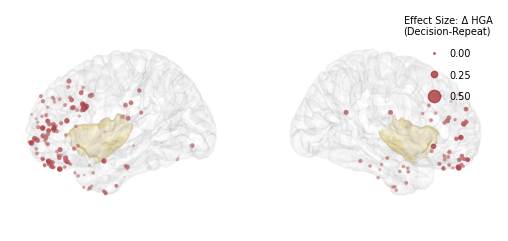

In [29]:
import numpy as np
import pyvista as pv
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from mne.viz import Brain
from scipy.spatial import cKDTree

labels = mne.read_labels_from_annot(
    subject='cvs_avg35_inMNI152', parc='aparc.a2009s',
    surf_name='pial',
    hemi='both', subjects_dir=recon_dir
)

lh_brain = Brain(
    "cvs_avg35_inMNI152", subjects_dir=recon_dir, surf="pial",
    hemi="lh", background="white", show=False,
    cortex=(0.9, 0.9, 0.9), alpha=0.1, size=(600*cm, 600*cm)
)
rh_brain = Brain(
    "cvs_avg35_inMNI152", subjects_dir=recon_dir, surf="pial",
    hemi="rh", background="white", show=False,
    cortex=(0.9, 0.9, 0.9), alpha=0.1, size=(600*cm, 600*cm)
)

# 使用显著数据进行可视化
cord = significant_delta[(significant_delta.direction=='Decision')][['x', 'y', 'z']].values
mean_delta = significant_delta[(significant_delta.direction=='Decision')]['mean_diff'].values

mask_lh = cord[:, 0] < 0
mask_rh = cord[:, 0] > 0

# Color + size mapping
cmap = reds
max_abs = np.percentile(np.abs(mean_delta), 95)
max_abs = max(max_abs, 1e-6)
norm = mcolors.TwoSlopeNorm(vmin=-max_abs, vcenter=0.0, vmax=max_abs)

size_min, size_max = 1, 35
alpha_min, alpha_max = 0.2, 0.9

def val_to_size(v, vmax_abs, size_min, size_max):
    x = np.clip(np.abs(v) / vmax_abs, 0, 1)
    return size_min + x * (size_max - size_min)

def val_to_alpha(v, vmax_abs, alpha_min, alpha_max):
    x = np.clip(np.abs(v) / vmax_abs, 0, 1)
    return alpha_min + x * (alpha_max - alpha_min)

def build_valid_vertex_mask(labels, hemi, n_vertices):
    m = np.zeros(n_vertices, dtype=bool)
    for lab in labels:
        if lab.hemi == hemi:
            m[lab.vertices] = True
    return m

def add_projected_points(brain, hemi, coords, vals, tree, surf_coords, valid_vertex_mask):
    if coords.size == 0:
        return

    _, indices = tree.query(coords)
    projected = surf_coords[indices]
    keep = valid_vertex_mask[indices]

    if not keep.any():
        return

    for pt, v in zip(projected[keep], vals[keep]):
        cloud = pv.PolyData(pt.reshape(1, 3))
        color = cmap(norm(v))[:3]
        size = val_to_size(v, max_abs, size_min, size_max)
        alpha = val_to_alpha(v, max_abs, alpha_min, alpha_max)
        brain._renderer.plotter.add_mesh(
            cloud,
            render_points_as_spheres=True,
            point_size=float(size),
            color=color,
            lighting=False,
            smooth_shading=False,
            opacity=float(alpha),
        )

lh_pial_path = f"{recon_dir}/cvs_avg35_inMNI152/surf/lh.pial"
lh_coords_pial, _ = mne.read_surface(lh_pial_path)
lh_tree = cKDTree(lh_coords_pial)
lh_valid_vertex = build_valid_vertex_mask(labels, 'lh', len(lh_coords_pial))

rh_pial_path = f"{recon_dir}/cvs_avg35_inMNI152/surf/rh.pial"
rh_coords_pial, _ = mne.read_surface(rh_pial_path)
rh_tree = cKDTree(rh_coords_pial)
rh_valid_vertex = build_valid_vertex_mask(labels, 'rh', len(rh_coords_pial))

if mask_lh.any():
    add_projected_points(
        lh_brain,
        'lh',
        cord[mask_lh],
        mean_delta[mask_lh],
        lh_tree,
        lh_coords_pial,
        lh_valid_vertex,
    )

if mask_rh.any():
    add_projected_points(
        rh_brain,
        'rh',
        cord[mask_rh],
        mean_delta[mask_rh],
        rh_tree,
        rh_coords_pial,
        rh_valid_vertex,
    )

insula_patterns = ['G_insular_short', 'G_Ins_lg_and_S_cent_ins',
                   'S_circular_insula_ant', 'S_circular_insula_inf', 'S_circular_insula_sup']
for lab in labels:
    if any(pattern in lab.name for pattern in insula_patterns):
        if lab.hemi == 'lh':
            lh_brain.add_label(lab, borders=False, color=insula_color, alpha=0.5)
        elif lab.hemi == 'rh':
            rh_brain.add_label(lab, borders=False, color=insula_color, alpha=0.5)


for brain in (lh_brain, rh_brain):
    brain.show_view(view="lateral", distance=400)
    brain._renderer.plotter.window_size = [1400, 1400]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16*cm, 8*cm), gridspec_kw={'width_ratios': [1, 1]})
# plt.subplots_adjust(wspace=0.02)
ax1.imshow(lh_brain.screenshot(mode="rgb"))
ax1.axis("off")

ax2.imshow(rh_brain.screenshot(mode="rgb"))
ax2.axis("off")

example_values = [0, max_abs * 0.5, max_abs]
example_labels = ['0.00', f'{max_abs * 0.5:.2f}', f'{max_abs:.2f}']

legend_scale = 0.35

handles = []
for v, lab in zip(example_values, example_labels):
    # PyVista point_size 是像素；Matplotlib markersize 是 points
    ps_px = val_to_size(v, max_abs, size_min, size_max)
    ms_pt = ps_px * 72.0 / fig.dpi * legend_scale
    h = plt.Line2D(
        [0], [0],
        marker='o',
        linestyle='None',
        markerfacecolor=red,
        markeredgecolor=red,
        markersize=max(1.0, ms_pt),
        alpha=0.8,
        label=lab,
    )
    handles.append(h)

ax2.legend(
    handles=handles,
    title='Effect Size: Δ HGA\n(Decision-Repeat)',
    loc='upper right',
    frameon=False,
    borderaxespad=0.2,
    handletextpad=0.6,
    labelspacing=1.2,
    fontsize=7,
    title_fontsize=7,
)

lh_brain.close()
rh_brain.close()

# fig.savefig(f'../img/fig4/fig4_spatial_condition_difference.svg', dpi=300, bbox_inches='tight')

Computing LH density:
  141 electrodes, 87471 vertices, density [0.041, 5.937]
Computing RH density:
  60 electrodes, 63854 vertices, density [0.056, 4.550]

Global density range: [0.0408, 5.9370]
AIC electrodes: LH=16, RH=6
Non-AIC electrodes: LH=125, RH=54
Effect size range for sizing: [0.000, 0.721]


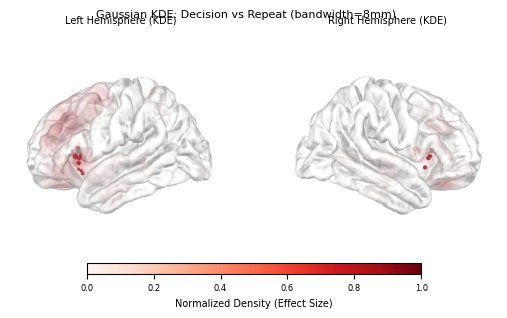

In [ ]:
# ========== 添加高斯核密度估计（KDE）热力图可视化 + 电极 overlay ==========
# 逻辑来自 fig6.ipynb: cdist + np.dot 向量化密度计算 + pyvista 电极叠加
from scipy.spatial.distance import cdist
from matplotlib.colors import ListedColormap
import pyvista as pv

# KDE参数设置
bandwidth = 8  # 高斯核带宽（mm）
max_distance = 15  # 最大影响距离（mm）
density_opacity = 0.5  # 有密度数据区域的不透明度（独立于brain表面）

def compute_density_unified(surface_coords, electrode_coords, effect_values, 
                            bandwidth=15, max_distance=30):
    """
    计算效应大小加权密度图（统一colormap版本）
    使用 cdist + np.dot 向量化计算
    """
    if len(electrode_coords) == 0:
        return np.zeros(len(surface_coords)), np.zeros(len(surface_coords), dtype=bool)
    
    # 计算所有顶点到所有电极的距离矩阵 (n_vertices, n_electrodes)
    distances = cdist(surface_coords, electrode_coords)
    min_distances = distances.min(axis=1)
    mask = min_distances < max_distance
    
    # 高斯核加权
    kernel_values = np.exp(-distances**2 / (2 * bandwidth**2))
    # 使用效应大小绝对值作为权重
    density = np.dot(kernel_values, np.abs(effect_values))
    density[~mask] = 0
    
    valid_vals = density[mask & (density > 0)]
    if len(valid_vals) > 0:
        print(f"  {len(electrode_coords)} electrodes, {mask.sum()} vertices, "
              f"density [{valid_vals.min():.3f}, {valid_vals.max():.3f}]")
    
    return density, mask


def add_electrodes_to_brain(brain, coords, effect_vals, surf_tree, surf_coords,
                            color, vmin, vmax, size_min=5, size_max=25, opacity=1.0):
    """将电极点投影到pial表面并添加为球体（来自fig6逻辑）"""
    if len(coords) == 0:
        return
    _, indices = surf_tree.query(coords)
    coords_on_pial = surf_coords[indices]
    
    for i in range(len(coords_on_pial)):
        pt = coords_on_pial[i:i+1]
        val = np.abs(effect_vals[i])
        normalized = np.clip((val - vmin) / (vmax - vmin), 0, 1)
        size = size_min + normalized * (size_max - size_min)
        
        cloud = pv.PolyData(pt)
        brain._renderer.plotter.add_mesh(
            cloud,
            render_points_as_spheres=True,
            point_size=size,
            color=color,
            lighting=False,
            smooth_shading=False,
            opacity=opacity,
        )

# ========== 准备数据（使用之前定义的变量） ==========
decision_data = significant_delta[(significant_delta.direction=='Decision')]
cord = decision_data[['x', 'y', 'z']].values
mean_delta = decision_data['mean_diff'].values
roi_values = decision_data['roi'].values

mask_lh = cord[:, 0] < 0
mask_rh = cord[:, 0] > 0

# ========== 第一遍：计算密度，确定全局范围 ==========
print("Computing LH density:")
lh_density, lh_mask = compute_density_unified(
    lh_coords_pial, cord[mask_lh], mean_delta[mask_lh],
    bandwidth=bandwidth, max_distance=max_distance
)

print("Computing RH density:")
rh_density, rh_mask = compute_density_unified(
    rh_coords_pial, cord[mask_rh], mean_delta[mask_rh],
    bandwidth=bandwidth, max_distance=max_distance
)

# 全局归一化
all_valid = np.concatenate([
    lh_density[lh_mask & (lh_density > 0)],
    rh_density[rh_mask & (rh_density > 0)]
])
global_vmin = all_valid.min() if len(all_valid) > 0 else 0
global_vmax = all_valid.max() if len(all_valid) > 0 else 1
print(f"\nGlobal density range: [{global_vmin:.4f}, {global_vmax:.4f}]")

# ========== 电极 overlay 参数 ==========
aic_mask = roi_values == 'AIC'
non_aic_mask = ~aic_mask
effect_vmin = 0
effect_vmax = np.percentile(np.abs(mean_delta), 95) if len(mean_delta) > 0 else 1
print(f"AIC electrodes: LH={np.sum(mask_lh & aic_mask)}, RH={np.sum(mask_rh & aic_mask)}")
print(f"Non-AIC electrodes: LH={np.sum(mask_lh & non_aic_mask)}, RH={np.sum(mask_rh & non_aic_mask)}")
print(f"Effect size range for sizing: [{effect_vmin:.3f}, {effect_vmax:.3f}]")

# ========== 创建统一的 Reds colormap ==========
n_colors = 1000
colors_list = []
# 0: 无数据区域 → 完全透明（alpha=0），让底层brain表面透出
colors_list.extend([[1, 1, 1, 1]] * 1)
# 1-999: 从白色渐变到橙色，使用独立的 density_opacity
import matplotlib.colors as mcolors
base_color = np.array(mcolors.to_rgb(red))
for i in range(1, n_colors):
    intensity = i / (n_colors - 1)
    color = (1 - intensity) * np.array([1, 1, 1]) + intensity * base_color
    colors_list.append(list(color) + [density_opacity])
custom_cmap = ListedColormap(colors_list)

# ========== 第二遍：可视化（密度 + 电极 overlay） ==========
view_configs = [
    ('lh', lh_density, lh_mask, lh_coords_pial, lh_tree),
    ('rh', rh_density, rh_mask, rh_coords_pial, rh_tree),
]


brains = []
for hemi, density, dmask, surf_coords, surf_tree in view_configs:
    brain = Brain(
        'fsaverage', subjects_dir=recon_dir, surf='pial', hemi=hemi,
        background='white', show=False,
        cortex=(0.95, 0.95, 0.95), alpha=0.2, size=(600*cm, 600*cm)
    )
    brain._renderer.plotter.window_size = [1400, 1400]

    # Layer 1: 归一化密度到 [0, n_colors-1] 用于 colormap 索引
    n_vertices = len(surf_coords)
    data_to_plot = np.zeros(n_vertices)
    has_data = dmask & (density > 0)
    if has_data.any():
        norm_density = np.clip(
            (density[has_data] - global_vmin) / (global_vmax - global_vmin), 0, 1
        )
        data_to_plot[has_data] = 1 + norm_density * (n_colors - 2)  # map to [1, n_colors-1]
    
    # 添加密度数据 — alpha=1.0 让colormap自身的alpha控制透明度
    brain.add_data(
        data_to_plot,
        hemi=hemi,
        colormap=custom_cmap,
        alpha=1.0,
        colorbar=False,
        fmin=0,
        fmax=n_colors - 1
    )
    
    # Layer 2: 叠加所有电极点
    hemi_mask = mask_lh if hemi == 'lh' else mask_rh
    
    # 先画非AIC电极（黑色，低透明度）
    other_mask = hemi_mask & non_aic_mask
    # if other_mask.any():
    #     add_electrodes_to_brain(
    #         brain,
    #         cord[other_mask],
    #         mean_delta[other_mask],
    #         surf_tree,
    #         surf_coords,
    #         color='black',
    #         vmin=effect_vmin,
    #         vmax=effect_vmax,
    #         size_min=10,
    #         size_max=35,
    #         opacity=0.5
    #     )
    
    # 再画AIC电极（红色），确保在蓝色上层
    aic_hemi_mask = hemi_mask & aic_mask
    if aic_hemi_mask.any():
        add_electrodes_to_brain(
            brain,
            cord[aic_hemi_mask],
            mean_delta[aic_hemi_mask],
            surf_tree,
            surf_coords,
            color=red,
            vmin=effect_vmin,
            vmax=effect_vmax,
            size_min=10,
            size_max=35
        )
    
    brain.show_view(view="lateral", distance=400)
    brains.append(brain)

# ========== 截图并绘制 matplotlib 图形 ==========
fig_kde, (ax1_kde, ax2_kde) = plt.subplots(
    1, 2, figsize=(16*cm, 8*cm), gridspec_kw={'width_ratios': [1, 1]}
)

ax1_kde.imshow(brains[0].screenshot(mode="rgb"))
ax1_kde.axis("off")
ax1_kde.set_title("Left Hemisphere (KDE)", fontsize=fontsize)

ax2_kde.imshow(brains[1].screenshot(mode="rgb"))
ax2_kde.axis("off")
ax2_kde.set_title("Right Hemisphere (KDE)", fontsize=fontsize)

# 添加colorbar
sm = plt.cm.ScalarMappable(cmap='Reds', norm=plt.Normalize(vmin=0, vmax=1))
sm.set_array([])
cbar = fig_kde.colorbar(sm, ax=[ax1_kde, ax2_kde], orientation='horizontal',
                        fraction=0.046, pad=0.04, aspect=30)
cbar.set_label('Normalized Density (Effect Size)', fontsize=fontsize)
cbar.ax.tick_params(labelsize=fontsize-1)

plt.suptitle(f'Gaussian KDE: Decision vs Repeat (bandwidth={bandwidth}mm)',
             fontsize=fontsize+1, y=0.95)

for b in brains:
    b.close()

fig_kde.savefig(f'../img/misc/task_modulate_decision_difference_KDE.svg', dpi=300, bbox_inches='tight')
plt.show()

Most electrodes ROI: OFCs (n=24)


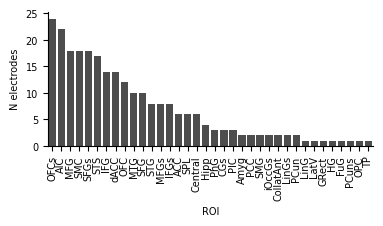

,roi,n_electrodes
19,OFCs,24
1,AIC,22
15,MFG,18
28,SMC,18
27,SFGs,18
32,STS,17
10,IFG,14
34,dACC,14
18,OFC,12
17,MTG,10


In [ ]:
coords_ = significant_delta[(significant_delta.phase=='delay')]

roi_counts = (
    coords_[['roi', 'channel']]
    .dropna(subset=['roi', 'channel'])
    .drop_duplicates()
    .groupby('roi', as_index=False)
    .agg(n_electrodes=('channel', 'nunique'))
    .sort_values('n_electrodes', ascending=False)
)

max_roi = roi_counts.iloc[0]['roi']
max_n = int(roi_counts.iloc[0]['n_electrodes'])
print(f"Most electrodes ROI: {max_roi} (n={max_n})")

top_n = 15
roi_counts_plot = roi_counts.head(top_n)

fig, ax = plt.subplots(figsize=(10*cm, 6*cm))
ax = sns.barplot(
    data=roi_counts,
    x='roi',
    y='n_electrodes',
    order=roi_counts['roi'],
    color='0.3',
)
ax.set_xlabel('ROI', fontdict=fontdict)
ax.set_ylabel('N electrodes', fontdict=fontdict)
ax.tick_params(axis='x', rotation=90, labelsize=fontsize)
ax.tick_params(axis='y', labelsize=fontsize)
sns.despine()
plt.tight_layout()
plt.show()

# fig.savefig('../img/fig4/fig4_RT_roi_counts.svg', dpi=300, bbox_inches='tight')
roi_counts.head(20)

# Plot